In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Interpolazione polinomiale a tratti


Indichiamo i dati del problema come le coppie
$$(x_i,y_i),\ \ i = 0,...,m+1 $$
In totale sono $m+2$ punti.

**Osservazione**: i nodi dei punti da interpolare definisicono una partizione dell'intervallo $[x_0,x_{m+1}]$.

Per indicare l'$i$-esimo sottointervallo della partizione utilizzeremo la notazione seguente
$$I_i = [x_i,x_{i+1}], \ \ i=0,...,m $$



Le tecniche di interpolazione lineare a tratti hanno lo scopo di definire una funzione interpolante $s(x)$ che se viene ristretta ad ogni intervallo della partizione è un polinomio di grado $n$, fissato a priori e indipendente dal numero dei punti.

In gemerale la funzione che si ottiene non è un polinomio in $[x_0,x_{m+1}]$.


#Interpolazione lineare a tratti
Il caso più semplice è quello lineare ($n=1$), in cui la funzione è la spezzata che unisce i punti da interpolare.

L'espressione analitica della spezzata si ottiene tenendo conto che è definita in modo diverso in ogni sottointervallo

$$s_i(x) = y_i + \frac{y_{i+1}-y_i}{x_{i+1}-x_i}(x-x_i), \ \ i=0,...,m+1 $$

$$s(x) = s_i(x), \ \ \text{ se } x\in [x_i,x_{i+1}] $$


#Esperimenti
Creiamo il grafico del polinomio di interpolazione e dell'interpolante lineare a tratti per le funzioni
$$\left(\frac{x+1}{2}\right)^2\sin(7(x+1)), \ \ x\in[-1,1] $$
$$\frac{1}{1+25x^2}, \ \ x\in [-1,1]$$

utilizzando nodi equispaziati negli intervalli indicati.

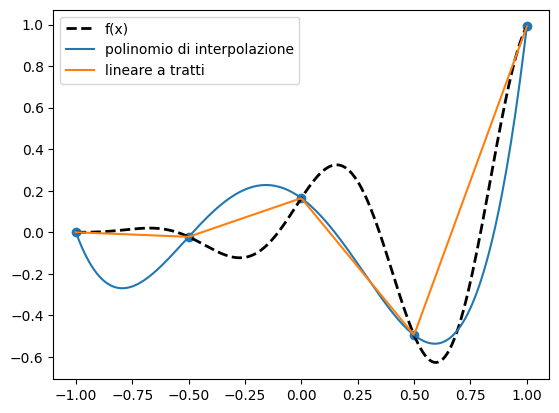

In [2]:
def polinomio_interpol(x,y,t):
  """
  calcolo del polinomio di interpolazione secondo il teorema fondamentale dell'algebra:
  grado del polinomio = numero dei punti - 1

  INPUT:
  x  : ascisse dei punti da interpolare (nodi)
  y  : ordinate dei punti da interpolare
  t  : array di punti in cui calcolare il polinomio di interpolazione costruito
       sui punti di coordinate (x,y)

  OUTPUT:
  array delle stesse dimensioni di xx contenente i valori del polinomio valutato nelle componenti di t
  """
  p = np.polyfit(x,y,x.size-1) #coefficienti del polinomio
  return np.polyval(p,t)

def piecewise_linear(x,y,t):
  n = x.size
  s = np.zeros(t.shape)
  for i in range(n-1):
    # Definisco una Bitmap che flagga solamente le 
    # componenti interne all'i-esimo intervallo
    ind = np.logical_and(t>=x[i],t<=x[i+1]) 
    # Applica la formula di interpolazione a tratti 
    # per l'i-esimo intervallo
    s[ind] = y[i] + ((y[i+1]-y[i])/(x[i+1]-x[i]))*(t[ind]-x[i])
  return s


interp_functions_list = [polinomio_interpol,piecewise_linear]
interp_function_names = ["polinomio di interpolazione","lineare a tratti"]



def crea_grafici(f,a,b,n,f_list,label_list):
  """
  funzione per creare i grafici della funzione f e delle funzioni che la interpolano
  in n nodi equispaziati in [a,b], i cui puntatori sono contenuti
  nella lsta f_list
  """
  #Creazione dei punti da interpolare
  x = np.linspace(a,b,n) #nodi equispaziati
  y = f(x)
  plt.scatter(x,y)

  #Creazione dei grafici
  xx = np.linspace(a,b,num=200)
  plt.plot(xx,f(xx),'--k',linewidth=2,label="f(x)")
  for i in range(len(f_list)):
    plt.plot(xx,f_list[i](x,y,xx),label=label_list[i])
  plt.legend()
  plt.show()
  return None



f1 = lambda x: np.sin(7*(x+1))*(x+1)**2/4
n = 5

crea_grafici(f1,-1,1,n,interp_functions_list,interp_function_names)


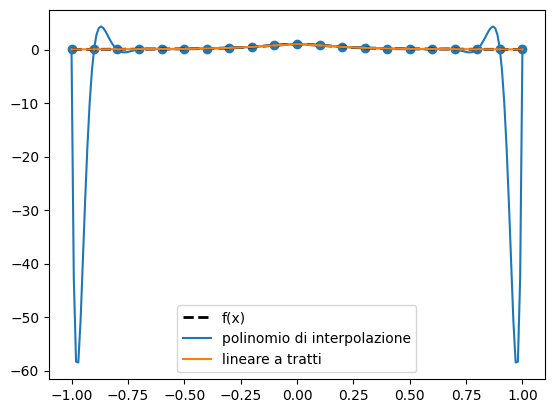

In [3]:
frunge = lambda x: 1/(1+25*x**2)
n = 21
crea_grafici(frunge,-1,1,n,interp_functions_list,interp_function_names)

**Vantaggi dell'interpolante lineare a tratti**
*   semplicità di implementazione
*   non è soggetta al fenomeno di Runge

**Svantaggi dell'interpolante lineare a tratti**
*   Occorrono molti punti per ottenere una buona approssimazione della funzione interpolata
*   L'interpolante è continua ma poco regolare: tutti i punti di interpolazione sono angolosi (non esiste la derivata prima).

#Le funzioni Spline
Le funzioni Spline sono polinomi a tratti di un grado fissato che si definiscono su una partizione di un intervallo.

La loro particolarità è di essere tanto più regolari quanto alto è il loro grado.

Possono essere utilizzate per interpolare dei punti nel piano ma vengono definite come classe di funzioni, indipendentemente dal problema dell'interpolazione.

**Definizione** Siano $x_0,...,x_{m+1}$ $m+2$ punti dell'intervallo $[a,b]$, con $a=x_0< x_1 <...< x_{m+1}=b$ e
sia $n$ un intero positivo. Una spline di grado $n$ relativa alla partizione $x_0,...,x_{m+1}$ è una funzione $s(x)$ tale che
1. $s(x)$ ristretta all'intervallo $[x_i,x_{i+1}]$ è un polinomio di grado al più $n$;
2. $s(x)$ è derivabile con continuità $n-1$ volte in $[a,b]$

#Spline di interpolazione
Dati $(x_i,y_i)$, $i=0,...,m+1$, si dice spline di interpolazione di grado $n$ una spline di grado $n$ costruita sulla partizione definita dai nodi che soddisfa le condizioni di interpolazione
$$s(x_i) = y_i, \ i=0,...,m+1 $$

**casi di interesse**
* $n=1$ => interpolante lineare a tratti (continua)
* $n=3$ => spline cubiche di interpolazione (derivabile due volte con continuità)

Per creare le spline cubiche in SciPy, si usa la funzione `CubicSpline`, la cui documentazione si trova [qui](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.CubicSpline.html#scipy.interpolate.CubicSpline).

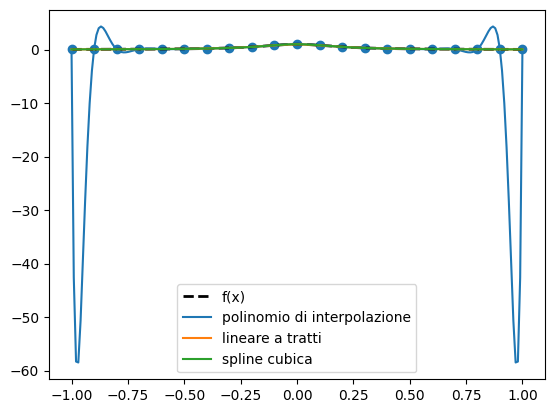

In [4]:
from scipy.interpolate import CubicSpline

def interp_spline3(x,y,xx):
  cs = CubicSpline(x,y)
  return cs(xx)

interp_functions_list.append(interp_spline3)#aggiungo la spline cubica di interpolazione alla lista
interp_function_names.append("spline cubica")
crea_grafici(frunge,-1,1,n,interp_functions_list,interp_function_names)


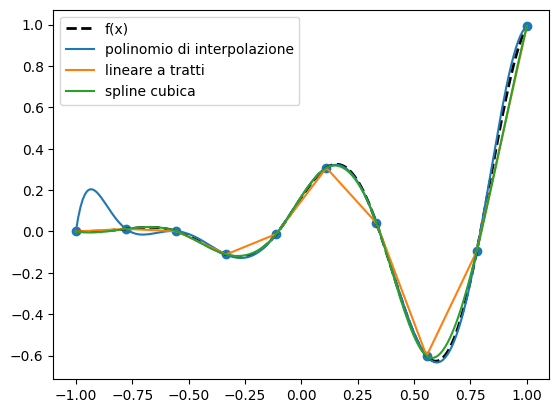

In [5]:
n = 10
crea_grafici(f1,-1,1,n,interp_functions_list,interp_function_names)